In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample, butter, filtfilt, find_peaks
from scipy.interpolate import CubicSpline

path =r"Data1.csv"
df = pd.read_csv(path, sep=',', header=0)
df.head()

,Time (s),PPG_Red,PPG_IR,PPG_Green,ECG,Temp_Ambient,Temp_Object,SpO2_Ground_Truth,HR_Ground_Truth
0,0.0000,29909,31863,86,1151,29.57,27.98,98,98
1,0.0025,29908,31853,97,1457,29.57,27.98,98,98
2,0.0050,29907,31875,102,1176,29.57,27.98,98,98
3,0.0075,29916,31872,93,1019,29.57,27.98,98,98
4,0.0100,29919,31868,86,1140,29.57,27.98,98,98


In [68]:
ppg_red = df['PPG_Red'].values
ppg_ir = df['PPG_IR'].values
time = df['Time (s)'].values
fs = len(ppg_red) / (time[-1] - time[0])
print("fs: ", fs)
print("jumlah sample: ", len(ppg_red))
print("durasi pengambilan data: ", time[-1] - time[0])

fs:  400.01612968264845
jumlah sample:  24800
durasi pengambilan data:  61.9975


In [69]:
# cut ke 24000 sample ~60 detik
red_cut = ppg_red[800:24800]
ir_cut = ppg_ir[800:24800]
time_cut = time[800:24800]
fs = len(red_cut) / (time_cut[-1] - time_cut[0])
print("fs: ", fs)
print("jumlah sample: ", len(red_cut))
print("durasi pengambilan data: ", time_cut[-1] - time_cut[0])

fs:  400.01666736114004
jumlah sample:  24000
durasi pengambilan data:  59.9975


In [70]:
# downsample ke 125 Hz
target_fs = 125
def downsample (x, fs, target_fs, time):
    x_resample = resample(x, int(len(x) * target_fs / fs))
    time_resample = np.linspace(time[0], time[-1], len(x_resample))
    return x_resample, time_resample

red_resample, time_resample = downsample(red_cut, fs, target_fs, time_cut)
ir_resample, _ = downsample(ir_cut, fs, target_fs, time_cut)
print("fs: ", len(red_resample) / (time_resample[-1] - time_resample[0]))
print("jumlah sample: ", len(red_resample))
print("durasi pengambilan data: ", time_resample[-1] - time_resample[0])

fs:  124.9885411892162
jumlah sample:  7499
durasi pengambilan data:  59.9975


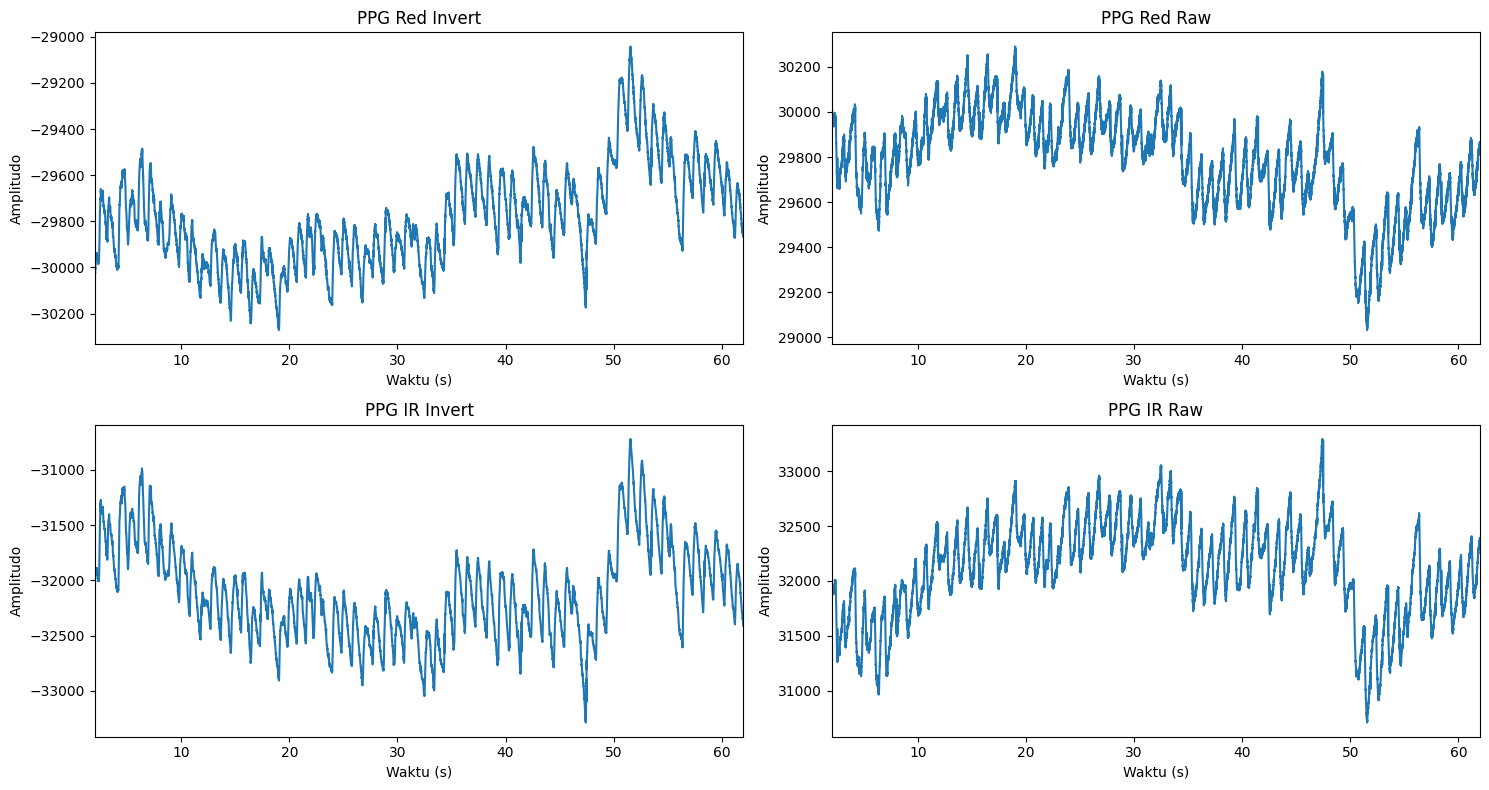

In [71]:
# invert sinyal
red_resample = -red_resample
ir_resample = -ir_resample

start = 2
end = 62
fig, ax = plt.subplots(2,2,figsize=(15,8))
ax = ax.flatten()

ax[0].plot(time_resample,red_resample)
ax[0].set_title('PPG Red Invert')
ax[0].set_xlabel('Waktu (s)')
ax[0].set_ylabel('Amplitudo')
ax[0].set_xlim(start, end)

ax[1].plot(time_cut,red_cut)
ax[1].set_title('PPG Red Raw')
ax[1].set_xlabel('Waktu (s)')
ax[1].set_ylabel('Amplitudo')
ax[1].set_xlim(start, end)

ax[2].plot(time_resample,ir_resample)
ax[2].set_title('PPG IR Invert')
ax[2].set_xlabel('Waktu (s)')
ax[2].set_ylabel('Amplitudo')
ax[2].set_xlim(start, end)

ax[3].plot(time_cut,ir_cut)
ax[3].set_title('PPG IR Raw')
ax[3].set_xlabel('Waktu (s)')
ax[3].set_ylabel('Amplitudo')
ax[3].set_xlim(start, end)

plt.tight_layout()
plt.show()

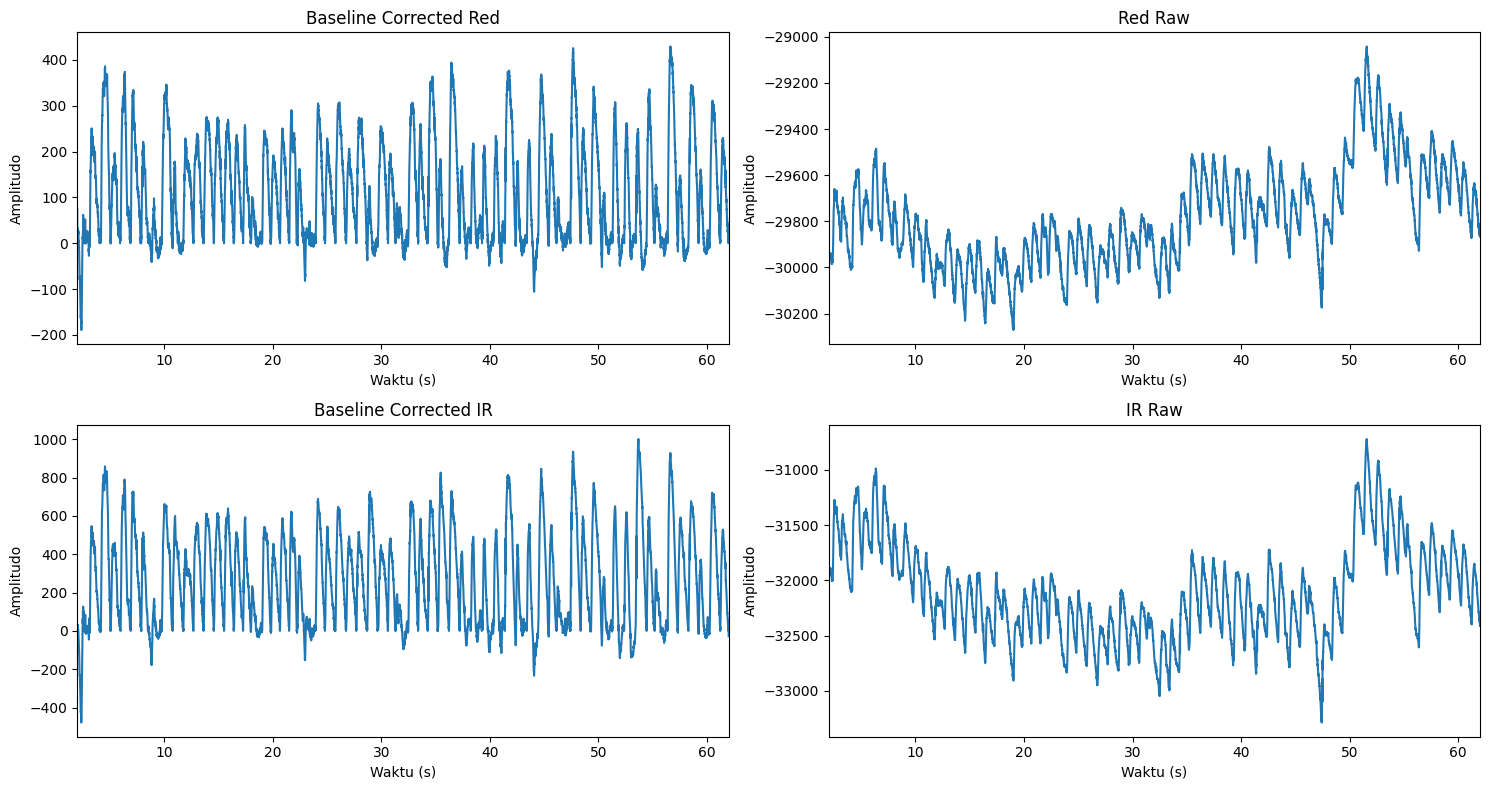

In [72]:
# baseline correction
def baseline_correction(time, x, fs=125):
    min_distance = int(0.5 * fs) 
    peaks, _ = find_peaks(-x, distance=min_distance, prominence=0.1)

    if len(peaks) < 2:
        raise ValueError('lembah terlalu sedikit untuk interpolasi')
    
    t_val = time[peaks]
    s_val = x[peaks]

    cs = CubicSpline(t_val, s_val, bc_type='natural')
    baseline_dc = cs(time)
    x_corrected = x - baseline_dc

    return x_corrected, baseline_dc

red_corrected, red_dc = baseline_correction(time_resample, red_resample)
ir_corrected, ir_dc = baseline_correction(time_resample, ir_resample)

fig, ax = plt.subplots(2,2,figsize=(15,8))
ax = ax.flatten()
start = 2
end = 62

ax[0].plot(time_resample,red_corrected)
ax[0].set_title("Baseline Corrected Red")
ax[0].set_xlabel("Waktu (s)")
ax[0].set_ylabel("Amplitudo")
ax[0].set_xlim(start, end)

ax[1].plot(time_resample,red_resample)
ax[1].set_title("Red Raw")
ax[1].set_xlabel("Waktu (s)")
ax[1].set_ylabel("Amplitudo")
ax[1].set_xlim(start, end)

ax[2].plot(time_resample,ir_corrected)
ax[2].set_title("Baseline Corrected IR")
ax[2].set_xlabel("Waktu (s)")
ax[2].set_ylabel("Amplitudo")
ax[2].set_xlim(start, end)

ax[3].plot(time_resample,ir_resample)
ax[3].set_title("IR Raw")
ax[3].set_xlabel("Waktu (s)")
ax[3].set_ylabel("Amplitudo")
ax[3].set_xlim(start, end)

plt.tight_layout()
plt.show()

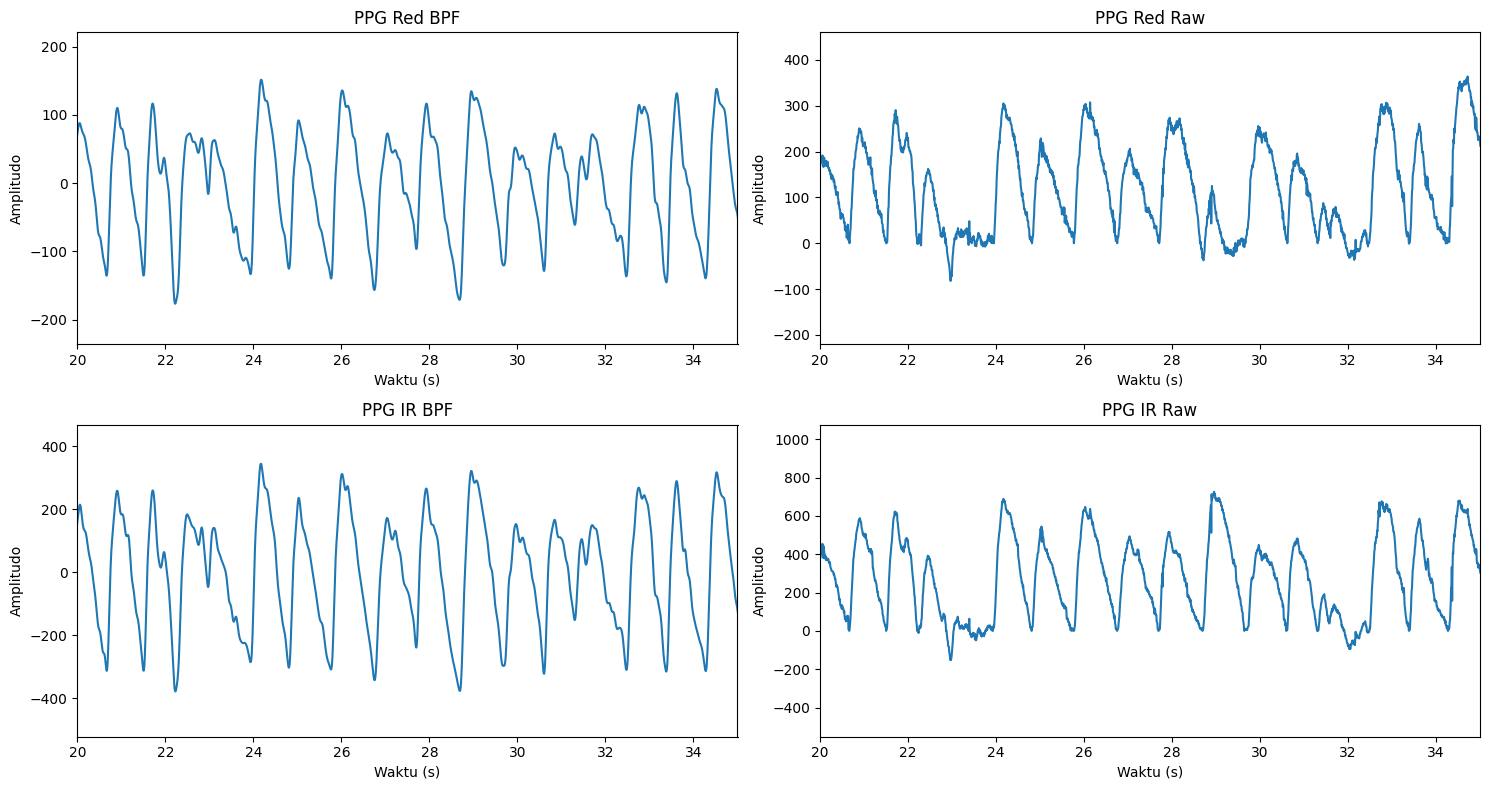

In [73]:
# preprocessing signal
def bandpass(x, low_cut, high_cut, fs = 125, order=4):
    nyq = 0.5 * fs
    low = low_cut / nyq
    high = high_cut / nyq
    b, a = butter(order, [low, high], btype='band')
    filtered_signal = filtfilt(b, a, x)
    return filtered_signal

red_bpf = bandpass(red_resample, 0.5, 10)
ir_bpf = bandpass(ir_resample, 0.5, 10)

start = 20
end = 35
fig, ax = plt.subplots(2,2,figsize=(15,8))
ax = ax.flatten()

ax[0].plot(time_resample,red_bpf)
ax[0].set_title('PPG Red BPF')
ax[0].set_xlabel('Waktu (s)')
ax[0].set_ylabel('Amplitudo')
ax[0].set_xlim(start, end)

ax[1].plot(time_resample,red_corrected)
ax[1].set_title('PPG Red Raw')
ax[1].set_xlabel('Waktu (s)')
ax[1].set_ylabel('Amplitudo')
ax[1].set_xlim(start, end)

ax[2].plot(time_resample,ir_bpf)
ax[2].set_title('PPG IR BPF')
ax[2].set_xlabel('Waktu (s)')
ax[2].set_ylabel('Amplitudo')
ax[2].set_xlim(start, end)

ax[3].plot(time_resample,ir_corrected)
ax[3].set_title('PPG IR Raw')
ax[3].set_xlabel('Waktu (s)')
ax[3].set_ylabel('Amplitudo')
ax[3].set_xlim(start, end)

plt.tight_layout()    
plt.show()

Banyak peak red:  64
Banyak peak ir:  67


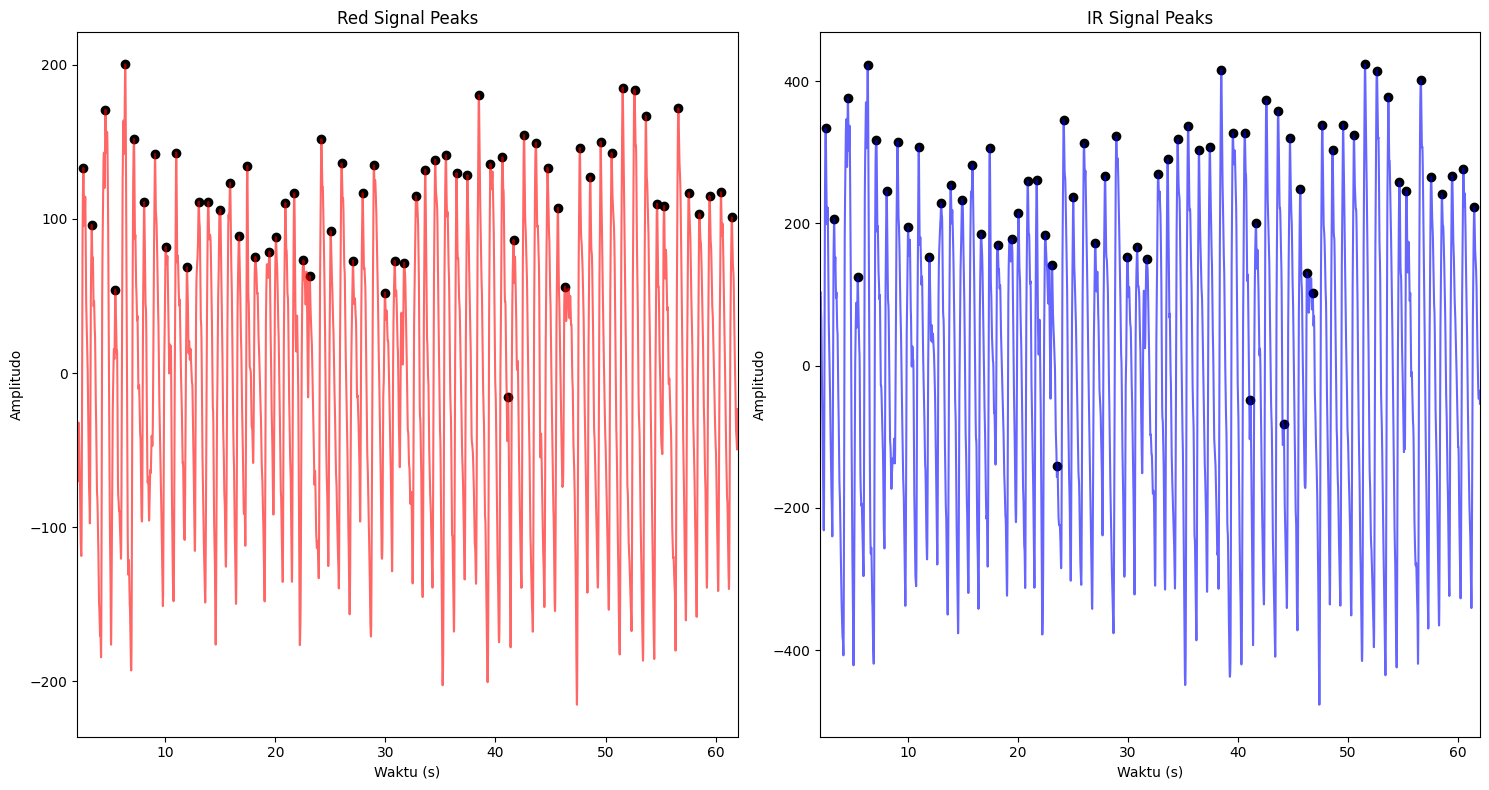

In [74]:
def ac_p2p(ac_signal, fs=125):
    min_distance = int(0.5 * fs)
    
    peaks, _ = find_peaks(ac_signal, distance=min_distance, prominence=10)
    troughs, _ = find_peaks(-ac_signal, distance=min_distance, prominence=10)
    
    num_beats = min(len(peaks), len(troughs))
    if num_beats == 0:
        return 0
        
    p2p_values = []
    for i in range(num_beats):
        amp = ac_signal[peaks[i]] - ac_signal[troughs[i]]
        p2p_values.append(amp)
        
    return np.mean(p2p_values), peaks

p2p_red, red_peaks = ac_p2p(red_bpf)
p2p_ir, ir_peaks = ac_p2p(ir_bpf)
print("Banyak peak red: ", len(red_peaks))
print("Banyak peak ir: ", len(ir_peaks))

fig, ax = plt.subplots(1,2,figsize=(15,8))
ax = ax.flatten()
start = 2
end = 62

ax[0].plot(time_resample, red_bpf, label="Red Filtered Signal", color="red", alpha=0.6)
ax[0].scatter(
    time_resample[red_peaks],  # <-- Modifikasi di sini
    red_bpf[red_peaks],
    color="black",
    marker="o",
    label="Detected Peaks",
)
ax[0].set_title("Red Signal Peaks")
ax[0].set_xlabel("Waktu (s)")
ax[0].set_ylabel("Amplitudo")
ax[0].set_xlim(start, end)

ax[1].plot(time_resample, ir_bpf, label="IR Filtered Signal", color="blue", alpha=0.6)
ax[1].scatter(
    time_resample[ir_peaks],
    ir_bpf[ir_peaks],
    color="black",
    marker="o",
    label="Detected Peaks",
)
ax[1].set_title("IR Signal Peaks")
ax[1].set_xlabel("Waktu (s)")
ax[1].set_ylabel("Amplitudo")
ax[1].set_xlim(start, end)

plt.tight_layout()
plt.show()

In [75]:
def Spo2(ac_ir, dc_ir, ac_red, dc_red):
    mean_dc_ir = np.mean(np.abs(dc_ir))
    mean_dc_red = np.mean(np.abs(dc_red))
    
    PI_red = ac_red / mean_dc_red
    PI_ir = ac_ir / mean_dc_ir

    R = PI_red / PI_ir
    spo2 = -17.8327 * (R**2) + (15.6006) * R + 94.6457
    spo2 = np.clip(spo2, 0, 100)
    return spo2, PI_red, PI_ir

spo2, PI_red, PI_ir = Spo2(p2p_ir, ir_dc, p2p_red, red_dc)
print("Spo2: ", spo2)
print("PI Red: ", PI_red)

Spo2:  98.01214665706172
PI Red:  0.008568783794956698
